In [8]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Get all of the Species objects defined in the GRI 3.0 mechanism
species = {S.name: S for S in ct.Species.list_from_file("gri30.yaml")}

# Create an ideal gas phase object with species representing complete combustion
complete_species = [species[S] for S in ("CH4", "O2", "N2", "CO2", "H2O")]
gas1 = ct.Solution(thermo="ideal-gas", species=complete_species)

In [10]:
phi = np.linspace(0.5, 2.0, 100)
T_complete = np.zeros(phi.shape)

for i in range(len(phi)):
    gas1.TP = 300, ct.one_atm
    gas1.set_equivalence_ratio(phi[i], "CH4", "O2:1, N2:3.76")
    gas1.equilibrate("HP")
    T_complete[i] = gas1.T


In [11]:
# Create an IdealGas object including incomplete combustion species
gas2 = ct.Solution(thermo="ideal-gas", species=species.values())
T_incomplete = np.zeros(phi.shape)
for i in range(len(phi)):
    gas2.TP = 300, ct.one_atm
    gas2.set_equivalence_ratio(phi[i], "CH4", "O2:1, N2:3.76")
    gas2.equilibrate("HP")
    T_incomplete[i] = gas2.T

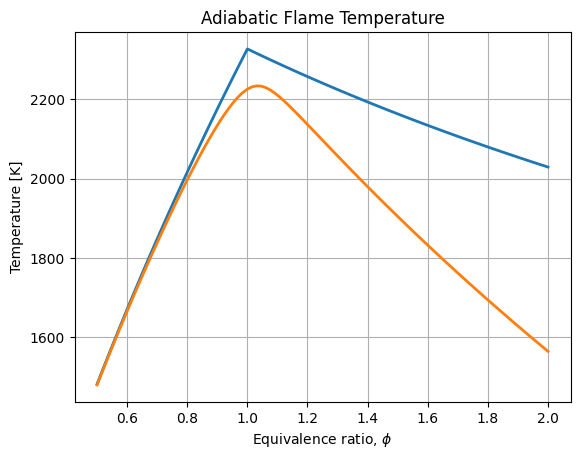

In [12]:
plt.plot(phi, T_complete, label="complete combustion", lw=2)
plt.plot(phi, T_incomplete, label="incomplete combustion", lw=2)
plt.grid(True)
plt.xlabel(r"Equivalence ratio, $\phi$")
_ = plt.ylabel("Temperature [K]")
plt.title("Adiabatic Flame Temperature")
plt.show()